---
title: "GSB 5544 Practice Application 3-1"

format:
  html:
    embed-resources: true
---

# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [40]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [41]:
# YOUR CODE HERE
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies_url = base + "movies.dat"
pd.read_csv(movies_url, sep = "::", encoding_errors = "ignore", header = None, names = ["movie_id", "title/year", "genre"])


<positron-console-cell-41>:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,movie_id,title/year,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [42]:
ratings_url = base + "ratings.dat"
pd.read_csv(ratings_url, sep="::", encoding_errors="ignore", header = None, names = ["user_id", "movie_id", "rating", "timestamp"])


<positron-console-cell-42>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [19]:
users_url = base + "users.dat"
pd.read_csv(users_url, sep="::", encoding_errors="ignore", header = None, names = ["user_id", "gender", "age", "occupation", "zip_code"])

<positron-console-cell-19>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


Occupation is chosen from the following choices:

	*  0:  "other" or not specified
	*  1:  "academic/educator"
	*  2:  "artist"
	*  3:  "clerical/admin"
	*  4:  "college/grad student"
	*  5:  "customer service"
	*  6:  "doctor/health care"
	*  7:  "executive/managerial"
	*  8:  "farmer"
	*  9:  "homemaker"
	* 10:  "K-12 student"
	* 11:  "lawyer"
	* 12:  "programmer"
	* 13:  "retired"
	* 14:  "sales/marketing"
	* 15:  "scientist"
	* 16:  "self-employed"
	* 17:  "technician/engineer"
	* 18:  "tradesman/craftsman"
	* 19:  "unemployed"
	* 20:  "writer"

Age is chosen from the following ranges:

	*  1:  "Under 18"
	* 18:  "18-24"
	* 25:  "25-34"
	* 35:  "35-44"
	* 45:  "45-49"
	* 50:  "50-55"
	* 56:  "56+"

In [43]:
movies = pd.read_csv(movies_url, sep = "::", encoding_errors = "ignore", header = None, names = ["movie_id", "title/year", "genre"])
ratings = pd.read_csv(ratings_url, sep="::", encoding_errors="ignore", header = None, names = ["user_id", "movie_id", "rating", "timestamp"])
users = pd.read_csv(users_url, sep="::", encoding_errors="ignore", header = None, names = ["user_id", "gender", "age", "occupation", "zip_code"])

<positron-console-cell-43>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-43>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-43>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [44]:
# YOUR CODE HERE
from numpy import inner
users.merge(ratings, on = "user_id", how = "inner").groupby("age")["rating"].mean().sort_values(ascending = False)

age
56    3.766632
50    3.714512
45    3.638062
35    3.618162
1     3.549520
25    3.545235
18    3.507573
Name: rating, dtype: float64

The 56 and older age group tend to give the highest ratings

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [45]:
# YOUR CODE HERE
movies.merge(ratings, on = "movie_id", how = "inner")
summary = movies.merge(ratings, on = "movie_id", how = "inner").groupby("title/year")["rating"].agg(["mean", "count"])
summary[summary["count"] >= 100].sort_values("mean")

,mean,count
title/year,,
Kazaam (1996),1.466667,120
Battlefield Earth (2000),1.611111,342
Pokmon the Movie 2000 (2000),1.620000,100
Aces: Iron Eagle III (1992),1.640000,125
Police Academy 6: City Under Siege (1989),1.657718,149
...,...,...
"Usual Suspects, The (1995)",4.517106,1783
"Close Shave, A (1995)",4.520548,657
"Godfather, The (1972)",4.524966,2223


The movie with the highest average rating is Seven Samurai

The movie with the lowest average rating is Kazaam

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

<Axes: xlabel='average_rating', ylabel='prop_18_24'>

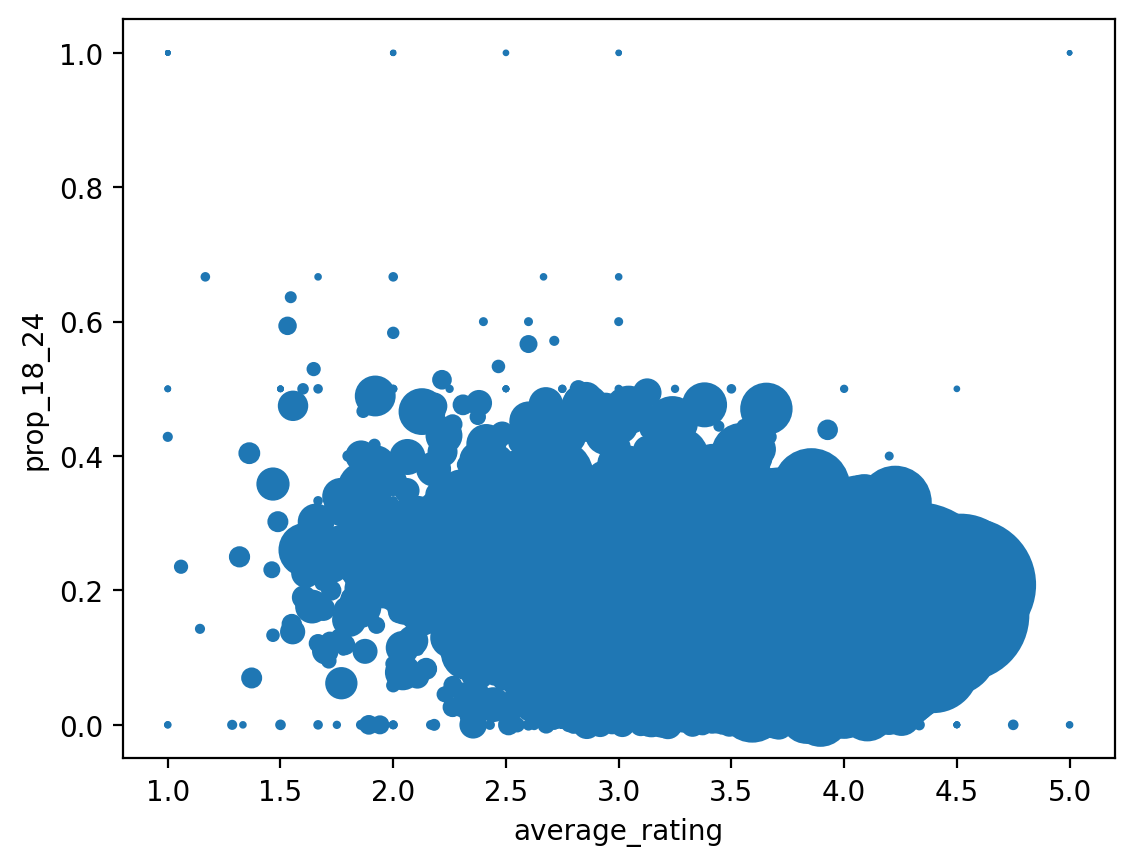

In [46]:
# YOUR CODE HERE
ratings_users = ratings.merge(users, on = "user_id", how = "inner")
ratings_users["age_18_24"] = ratings_users["age"] == 18

movie_summary = ratings_users.groupby("movie_id").agg(
    average_rating = ("rating", "mean"),
    prop_18_24 = ("age_18_24", "mean"),
    number_ratings = ("rating", "count")
)

movie_summary.plot.scatter(
    x = "average_rating",
    y = "prop_18_24",
    s = "number_ratings"
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [47]:
# YOUR CODE HERE
movie_counts = movies.merge(ratings, on = "movie_id", how = "left").groupby("movie_id")["rating"].count()
movie_counts

movie_id
1       2077
2        701
3        478
4        170
5        296
        ... 
3948     862
3949     304
3950      54
3951      40
3952     388
Name: rating, Length: 3883, dtype: int64

In [48]:
(movie_counts == 0).sum()

np.int64(177)

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [50]:
# YOUR CODE HERE
one_star = ratings[ratings["rating"] == 1].groupby("movie_id").size()

five_star = ratings[ratings["rating"] == 5].groupby("movie_id").size()

both = one_star.to_frame("one_star").merge(
    five_star.to_frame("five_star"),
    on="movie_id"
)

both = both.merge(movies[["movie_id", "title/year"]], on="movie_id")

both

,movie_id,one_star,five_star,title/year
0,1,16,820,Toy Story (1995)
1,2,42,48,Jumanji (1995)
2,3,44,43,Grumpier Old Men (1995)
3,4,21,6,Waiting to Exhale (1995)
4,5,28,16,Father of the Bride Part II (1995)
...,...,...,...,...
2981,3948,35,163,Meet the Parents (2000)
2982,3949,9,132,Requiem for a Dream (2000)
2983,3950,2,12,Tigerland (2000)
2984,3951,1,14,Two Family House (2000)


In [51]:
len(both)

2986